In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from feature_analysis import FeatureDistributionPlotter
from feature_engine.selection import DropHighPSIFeatures
from phik import report  # also registers the df.phik_matrix() pandas extension


#### Configuration

In [2]:
# ── Random state ──────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Dataset generation ─────────────────────────────────────────────────────────
NUM_SAMPLES            = 1_000
NUM_NUMERIC_FEATURES   = 5
NUM_CATEGORICAL_FEATURES = 3

# Non-linear feature: y = exp(NL_SCALE * x + noise)
# exp() is strictly monotonic  →  Spearman ≈ 1.0
# but exponentially non-linear →  Pearson  ≪ 1.0
# Raise NL_SCALE to widen the gap further.
NL_SCALE     = 2    # exponential growth rate
NL_NOISE_STD = 0.1  # injected into the exponent (multiplicative noise)

# ── Train / test split ─────────────────────────────────────────────────────────
TRAIN_SIZE = 0.8

# ── PSI ────────────────────────────────────────────────────────────────────────
PSI_THRESHOLD        = 0.25
PSI_SHIFT_MULTIPLIER = 10_000_000

# ── PhiK correlation report ────────────────────────────────────────────────────
PHIK_SIGNIFICANCE_THRESHOLD = 3
PHIK_CORRELATION_THRESHOLD  = 0.5
# ── High-Pearson / Low-Spearman feature ──────────────────────────────────────
# y = x + NL2_BUMP_AMP * exp(-x^2 / NL2_BUMP_WIDTH) + noise
# A Gaussian bump centred at x=0 inflates y for typical (middle) x values above
# where large-x values land, creating rank inversions near the centre.
# Extreme (x, y) pairs stay linear → Pearson stays up.
NL2_BUMP_AMP   = 2.0  # bump height; raise to widen the Pearson / Spearman gap
NL2_BUMP_WIDTH = 0.5  # controls how wide the bump is (variance of the Gaussian)
NL2_NOISE_STD  = 0.3  # additive noise

#### 1. Generate random numeric features

In [3]:
numeric_features = pd.DataFrame(
    np.random.randn(NUM_SAMPLES, NUM_NUMERIC_FEATURES),
    columns=[f'num_feature_{i+1}' for i in range(NUM_NUMERIC_FEATURES)],
)

#### 2. Generate a few categorical features

In [4]:
categorical_data = {
    f'cat_feature_{i+1}': np.random.choice(['A', 'B', 'C', 'D'], size=NUM_SAMPLES)
    for i in range(NUM_CATEGORICAL_FEATURES)
}
categorical_features = pd.DataFrame(categorical_data)

#### 3. Generate a binary label
Let's make the label somewhat dependent on some numeric and categorical features

In [5]:
label = (
    0.3 * numeric_features['num_feature_1']
    + 0.5 * numeric_features['num_feature_2']
    + (categorical_features['cat_feature_1'] == 'A').astype(int) * 0.8
    + np.random.randn(NUM_SAMPLES) * 0.5
    > 0.5
).astype(int)

#### 4. Create a non-linear but monotonic feature
`num_feature_nonlinear_corr = exp(NL_SCALE · x + noise)` is **strictly monotonic** (every rank is preserved → Spearman ≈ 1), yet **exponentially non-linear** (the linear fit is poor → Pearson ≪ 1). This maximises the gap between the two metrics, making it clearly visible in the scatter plot.

In [6]:
x = numeric_features['num_feature_1']
num_feature_nonlinear_corr = np.exp(
    NL_SCALE * x + np.random.randn(NUM_SAMPLES) * NL_NOISE_STD
)

#### 5. Create a feature with high Pearson but lower Spearman
`y = x + NL2_BUMP_AMP · exp(-x² / NL2_BUMP_WIDTH) + noise`

A Gaussian bump centred at x=0 inflates the y values of *typical* (middle) x values above where *extreme* x values land. Because extreme (x, y) pairs remain linear, Pearson — which weights values by their magnitude — stays strong. But many ordinary x values end up with a *higher y rank* than larger x values, creating rank inversions that visibly suppress Spearman. The scatter looks like an almost-linear cloud with a gentle arch.

In [7]:
num_feature_pearson_driven = (
    x
    + NL2_BUMP_AMP * np.exp(-x**2 / NL2_BUMP_WIDTH)
    + np.random.randn(NUM_SAMPLES) * NL2_NOISE_STD
)

#### 6. Create an ad-hoc categorical correlated variable for PhiK
We'll make 'cat_feature_corr' correlated with 'cat_feature_1'

In [8]:
cat_feature_corr = []
for val in categorical_features['cat_feature_1']:
    if val == 'A':
        # High chance of being 'X'
        cat_feature_corr.append(np.random.choice(['X', 'Y', 'Z'], p=[0.7, 0.2, 0.1]))
    elif val == 'B':
        # High chance of being 'Y'
        cat_feature_corr.append(np.random.choice(['X', 'Y', 'Z'], p=[0.1, 0.8, 0.1]))
    else:
        # More random
        cat_feature_corr.append(np.random.choice(['X', 'Y', 'Z'], p=[0.3, 0.3, 0.4]))
cat_feature_corr = pd.Series(cat_feature_corr, name='cat_feature_corr')

#### Combine all features into a single DataFrame

In [9]:
dataset = pd.concat([
    numeric_features,
    categorical_features,
    pd.Series(num_feature_nonlinear_corr, name='num_feature_nonlinear_corr'),
    pd.Series(num_feature_pearson_driven, name='num_feature_pearson_driven'),
    cat_feature_corr,
    pd.Series(label, name='target'),
], axis=1)

dataset.head()

,num_feature_1,num_feature_2,num_feature_3,num_feature_4,num_feature_5,cat_feature_1,cat_feature_2,cat_feature_3,num_feature_nonlinear_corr,num_feature_pearson_driven,cat_feature_corr,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,D,C,C,2.590796,1.944857,Y,1
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,A,B,D,0.582338,1.482389,X,1
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,D,C,C,0.408448,-0.134218,X,0
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,B,C,D,0.313339,0.589560,Y,0
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,D,A,C,20.171583,1.492339,Z,0


### Let's Split in training and test

In [10]:
n_split       = int(TRAIN_SIZE * len(dataset))
dataset_train = dataset[:n_split]
dataset_test  = dataset[n_split:]

print(f"Train : {dataset_train.shape}  |  positive rate: {dataset_train['target'].mean():.2%}")
print(f"Test  : {dataset_test.shape}   |  positive rate: {dataset_test['target'].mean():.2%}")

Train : (800, 12)  |  positive rate: 36.88%
Test  : (200, 12)   |  positive rate: 35.00%


### Feature Distribution Overview
Before diving into feature elimination, let's visualise how each feature is distributed across the train and test sets. Any feature that looks very different between splits is a candidate for PSI-based removal.

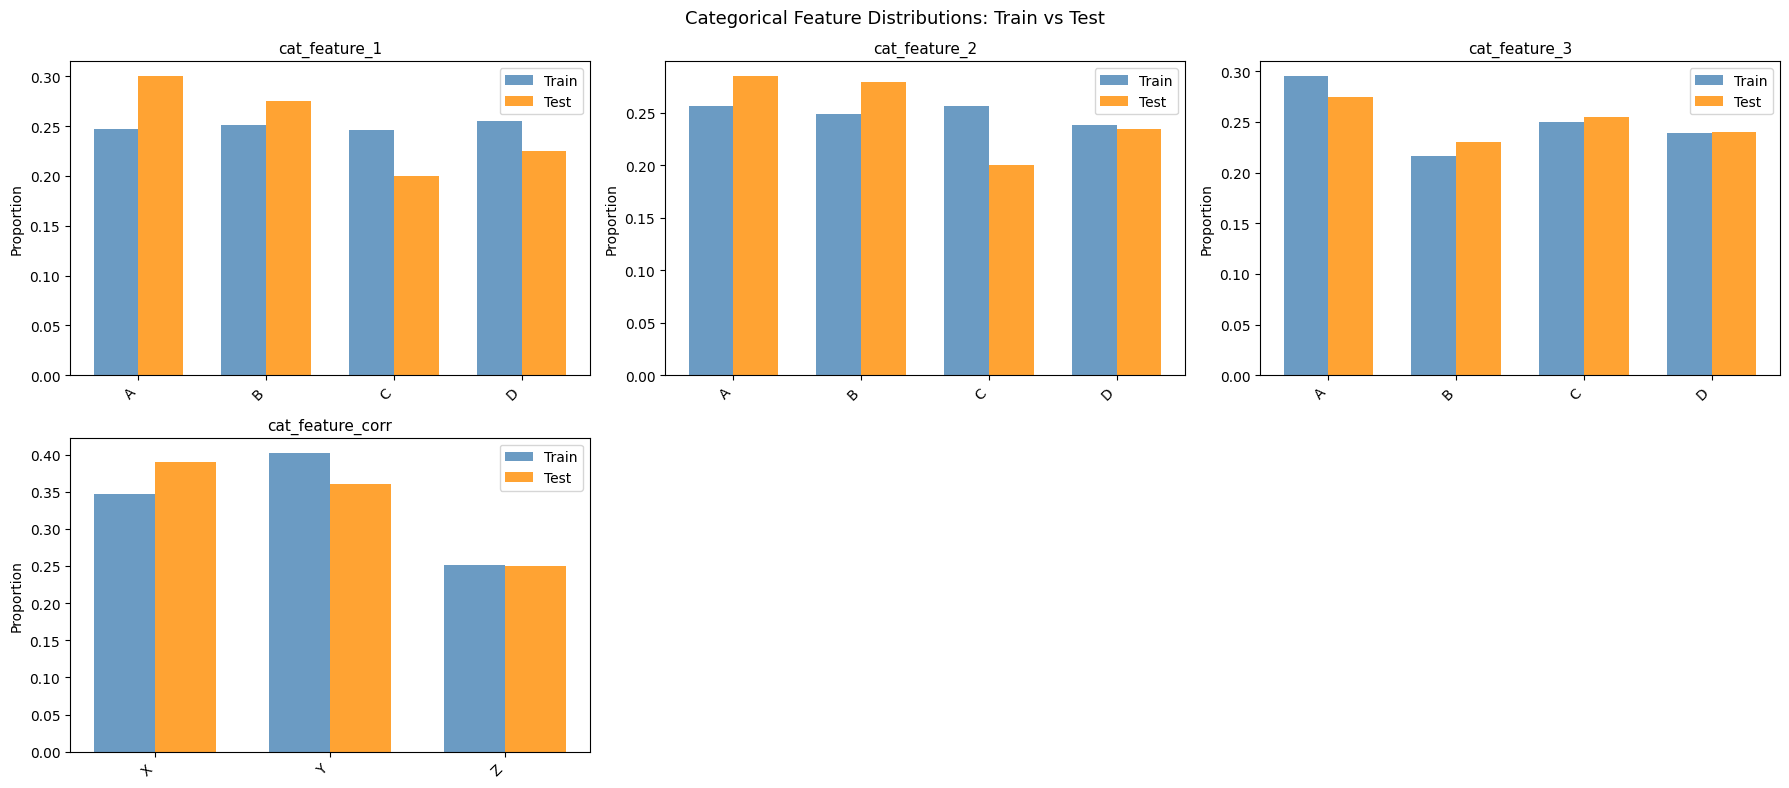

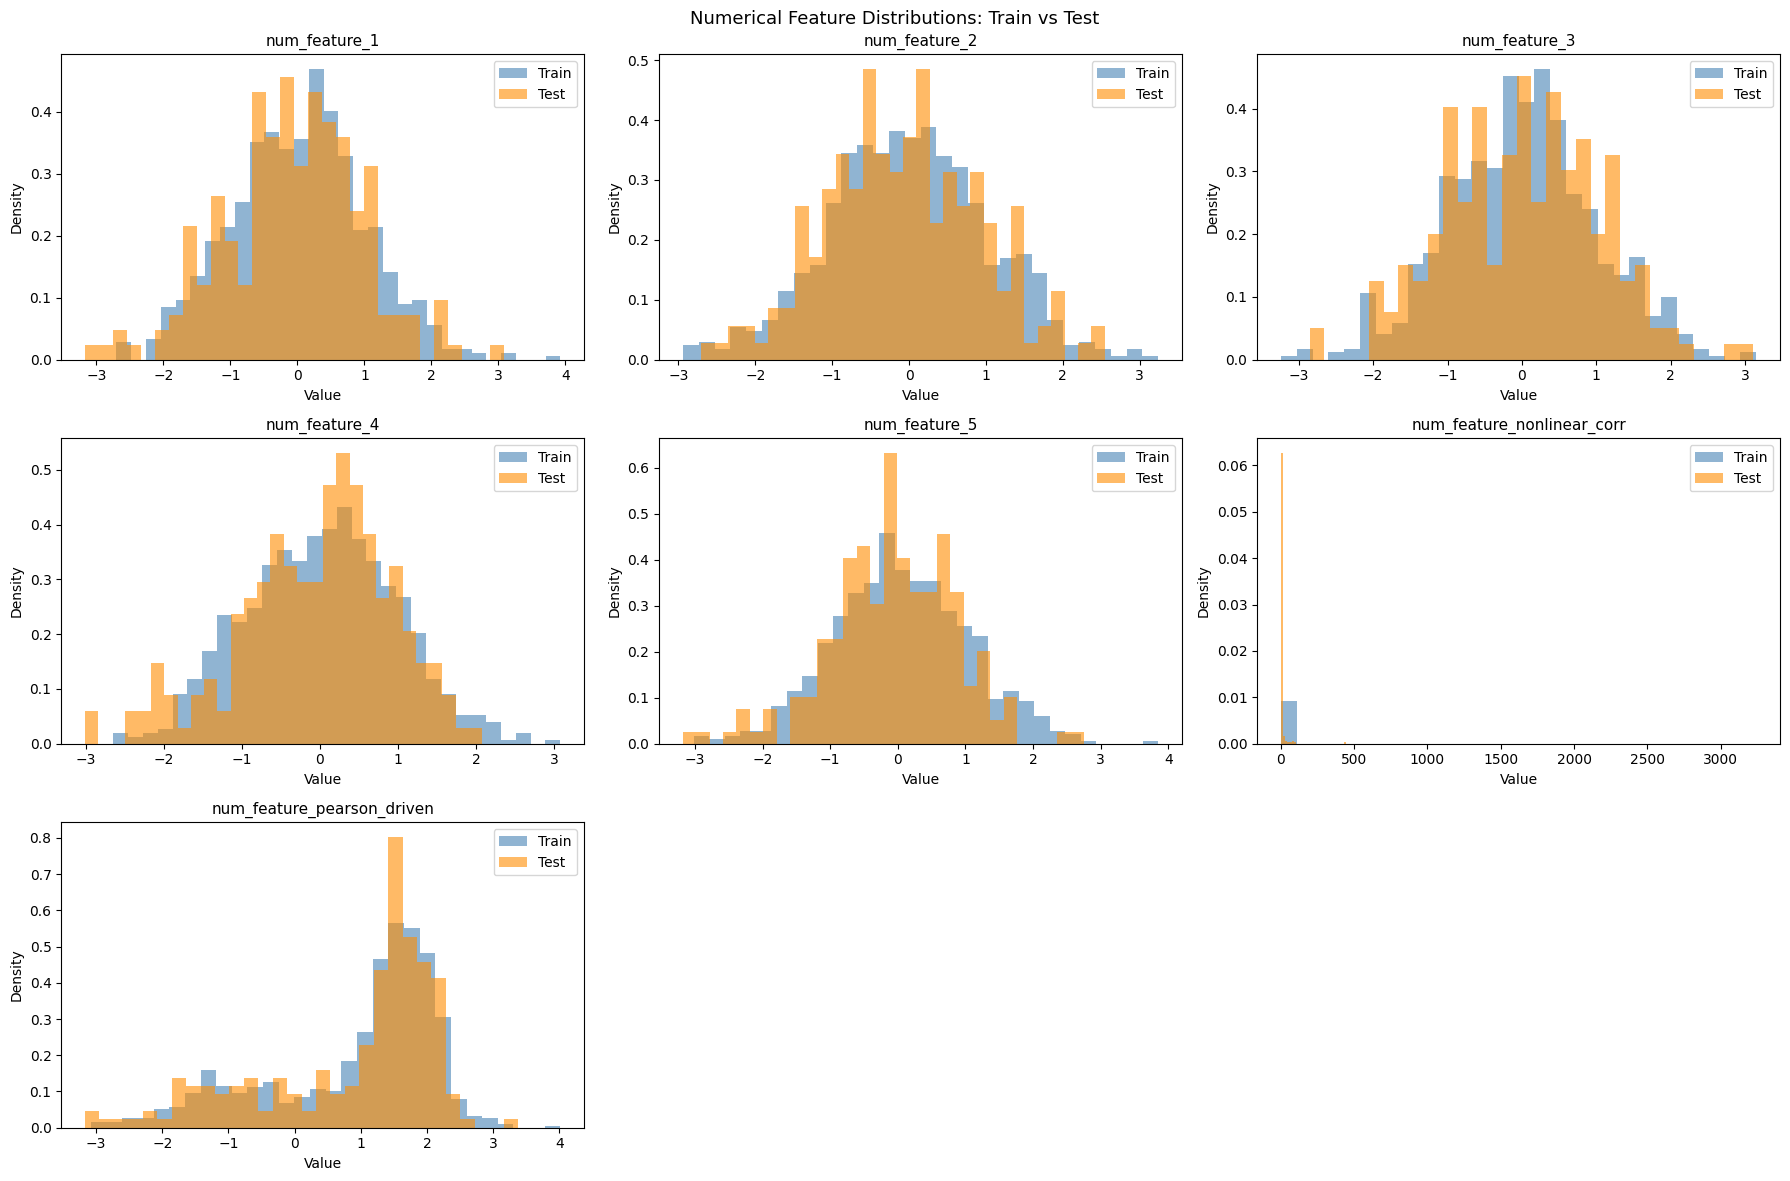

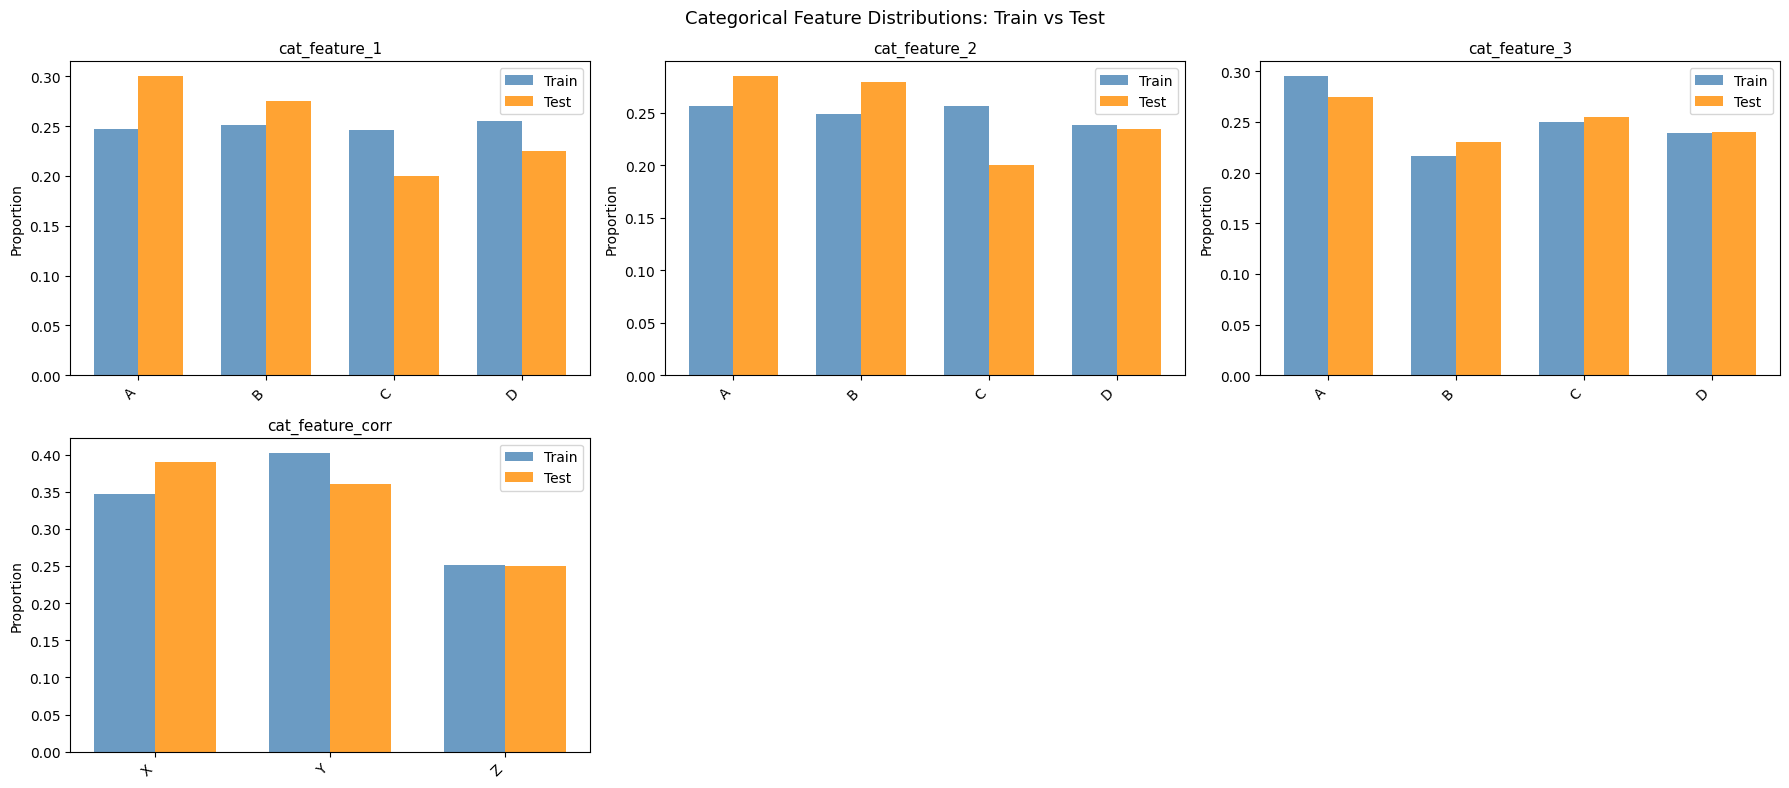

In [11]:
plotter = FeatureDistributionPlotter(dataset_train)

plotter.plot_numerical_distributions(dataset_train, dataset_test)
plotter.plot_categorical_distributions(dataset_train, dataset_test)

#### Let's Apply PSI
* For [PSI I use the feature engine library](https://feature-engine.trainindata.com/en/1.8.x/user_guide/selection/DropHighPSIFeatures.html), I found that a great source for the feature engineering transformation and I suggest to deep dive to other methods if you are not an expert of it

* [Citing their documentation](https://feature-engine.trainindata.com/en/1.8.x/user_guide/selection/DropHighPSIFeatures.html#threshold)
  * I discard a feature if the PSI value is higher than **0.25**
  * If unsure they mention you can also use the `auto` value

* Your dataset must be ordered for your reference date - in my case since I randomly generated everything I considered everything already ordered and I did not need to ensure the time ordering of the dataframe.

In [12]:
drop_psi = DropHighPSIFeatures(
    threshold=PSI_THRESHOLD,
    missing_values='ignore',
    split_frac=TRAIN_SIZE,
)
drop_psi.fit(X=dataset)
features_to_drop_psi = drop_psi.features_to_drop_

print(f"{len(features_to_drop_psi)} features to drop based on PSI > {PSI_THRESHOLD}:")
features_to_drop_psi

0 features to drop based on PSI > 0.25:


[]

#### Interpreting PSI
| PSI value | Interpretation | Action |
|---|---|---|
| < 0.1 | No significant shift | Keep the feature |
| 0.1 – 0.25 | Moderate shift — worth monitoring | Keep, but flag for review |
| > 0.25 | Major shift | **Drop** — the feature behaves differently in train vs test |

With stable synthetic data all features pass. In the next cell we force a distribution shift on `num_feature_2` to show what a real drift looks like.

#### Simulating a distribution shift
In the real world a shift can happen when: the data pipeline changes, the population changes seasonally, or a feature is computed differently in production. Here we multiply the training values of `num_feature_2` by a large constant to mimic an abrupt upstream change.

In [13]:
dataset.loc[:n_split - 1, "num_feature_2"] = (
    PSI_SHIFT_MULTIPLIER * dataset.loc[:n_split - 1, "num_feature_2"]
)

In [14]:
drop_psi = DropHighPSIFeatures(
    threshold=PSI_THRESHOLD, # "auto" can be used here if you prefer to let them decide
    missing_values='ignore',
    split_frac=TRAIN_SIZE
)
drop_psi.fit(X=dataset)

features_to_drop_psi = drop_psi.features_to_drop_

print(f"{len(features_to_drop_psi)} features to drop based on PSI > {PSI_THRESHOLD}:")

features_to_drop_psi

1 features to drop based on PSI > 0.25:


['num_feature_2']

In [15]:
drop_psi.psi_values_

{'num_feature_1': np.float64(0.06948409289085317),
 'num_feature_2': np.float64(8.283089355027482),
 'num_feature_3': np.float64(0.06408268277207117),
 'num_feature_4': np.float64(0.030765537922726228),
 'num_feature_5': np.float64(0.09055803954488664),
 'num_feature_nonlinear_corr': np.float64(0.03223870631680055),
 'num_feature_pearson_driven': np.float64(0.04543806018290241),
 'target': np.float64(0.0)}

#### Decision: drop `num_feature_2`
`num_feature_2` now has PSI >> 0.25, meaning its distribution in the training window is completely different from the test window. Any model trained on this feature would learn a pattern that does not exist in production — a textbook case for PSI-based removal.

The remaining features all have PSI < 0.1, so they are safe to keep.

### Applying numerical correlation
* Using pandas is simply as calling just one function if you prefer having everything in a pipeline you can concatenate things and use another [feature engine pipeline step](https://feature-engine.trainindata.com/en/latest/user_guide/selection/DropCorrelatedFeatures.html)

In [16]:
num_cols = plotter.num_cols
num_cols

['num_feature_1',
 'num_feature_2',
 'num_feature_3',
 'num_feature_4',
 'num_feature_5',
 'num_feature_nonlinear_corr',
 'num_feature_pearson_driven']

#### What to look for in the heatmap
Flag any pair with **|r| > 0.9** (strict threshold) or **|r| > 0.7** (lenient).

| Scenario | Which metric | Decision |
|---|---|---|
| Linear model (Logistic Regression, Linear Regression) | **Pearson** | Drop one feature of any highly-linearly-correlated pair to reduce multicollinearity |
| Tree-based model (Random Forest, GBM) | **Spearman** | Drop one feature of any highly-monotonically-correlated pair — trees are immune to linear collinearity but redundant monotonic features still slow training and hurt interpretability |

In our dataset: `num_feature_nonlinear_corr` is **highly Spearman-correlated** with `num_feature_1` (monotonic exp relationship) but **low Pearson** — a linear model would keep both, while a tree-based screen would drop one. `num_feature_pearson_driven` shows the opposite: **high Pearson**, lower Spearman — a linear model screen would catch it, a Spearman-only screen would miss it.

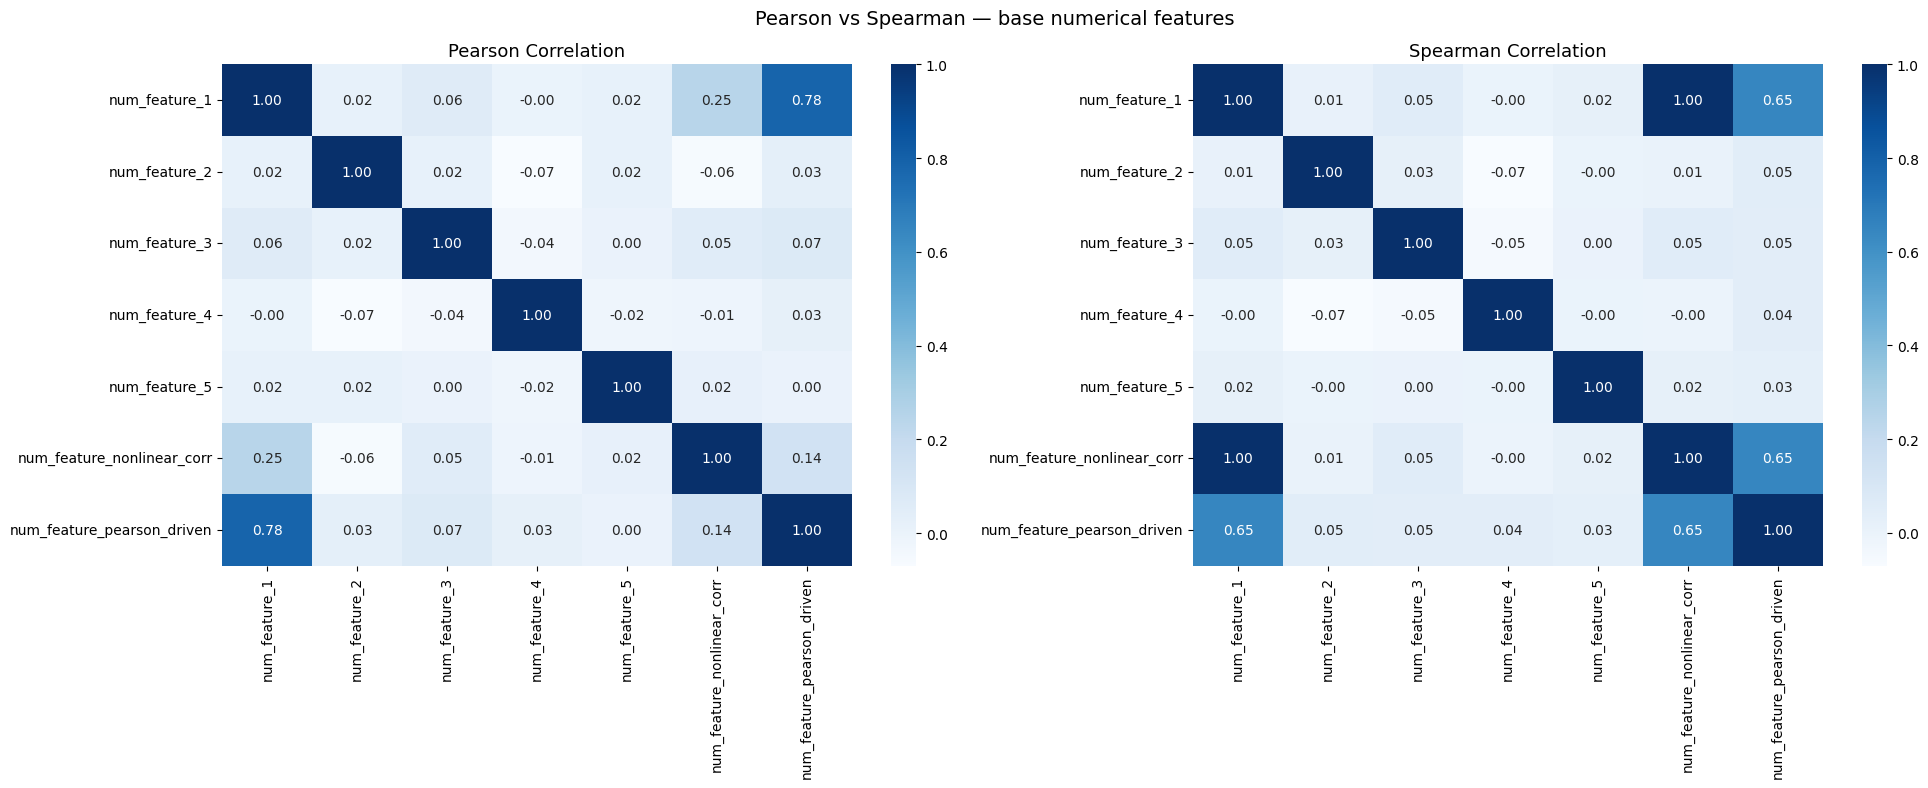

In [17]:
pearson_corr  = dataset_train[num_cols].corr(method='pearson')
spearman_corr = dataset_train[num_cols].corr(method='spearman')

_ = plotter.plot_comparison_heatmaps(
    pearson_corr,
    spearman_corr,
    title_a='Pearson Correlation',
    title_b='Spearman Correlation',
    suptitle='Pearson vs Spearman — base numerical features',
)

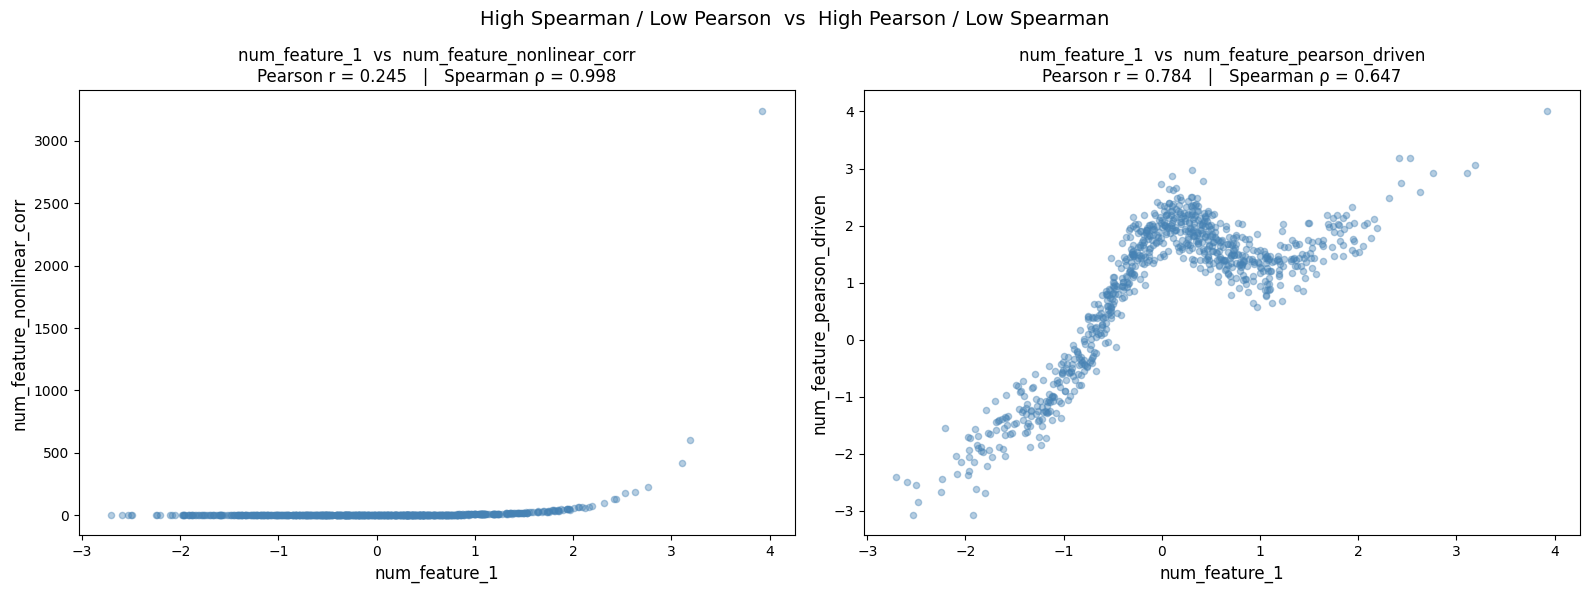

In [18]:
_ = plotter.plot_scatter_comparison(
    dataset_train,
    pairs=[
        ('num_feature_1', 'num_feature_nonlinear_corr'),
        ('num_feature_1', 'num_feature_pearson_driven'),
    ],
    suptitle='High Spearman / Low Pearson  vs  High Pearson / Low Spearman',
)

#### Reading the scatter plots
**Left — high Spearman, low Pearson** (`num_feature_nonlinear_corr`): the hockey-stick shape means every rank is respected (monotonic) but the linear fit is poor. A Spearman screen catches this; Pearson misses it.

**Right — high Pearson, lower Spearman** (`num_feature_pearson_driven`): the scatter looks almost linear with a subtle arch. A few rank inversions near the centre suppress Spearman while Pearson stays strong because the extreme (x, y) pairs dominate the covariance sum.

> **Rule of thumb:** use Pearson to screen for linear models; use Spearman for tree-based models — and compare both to catch edge cases like these.

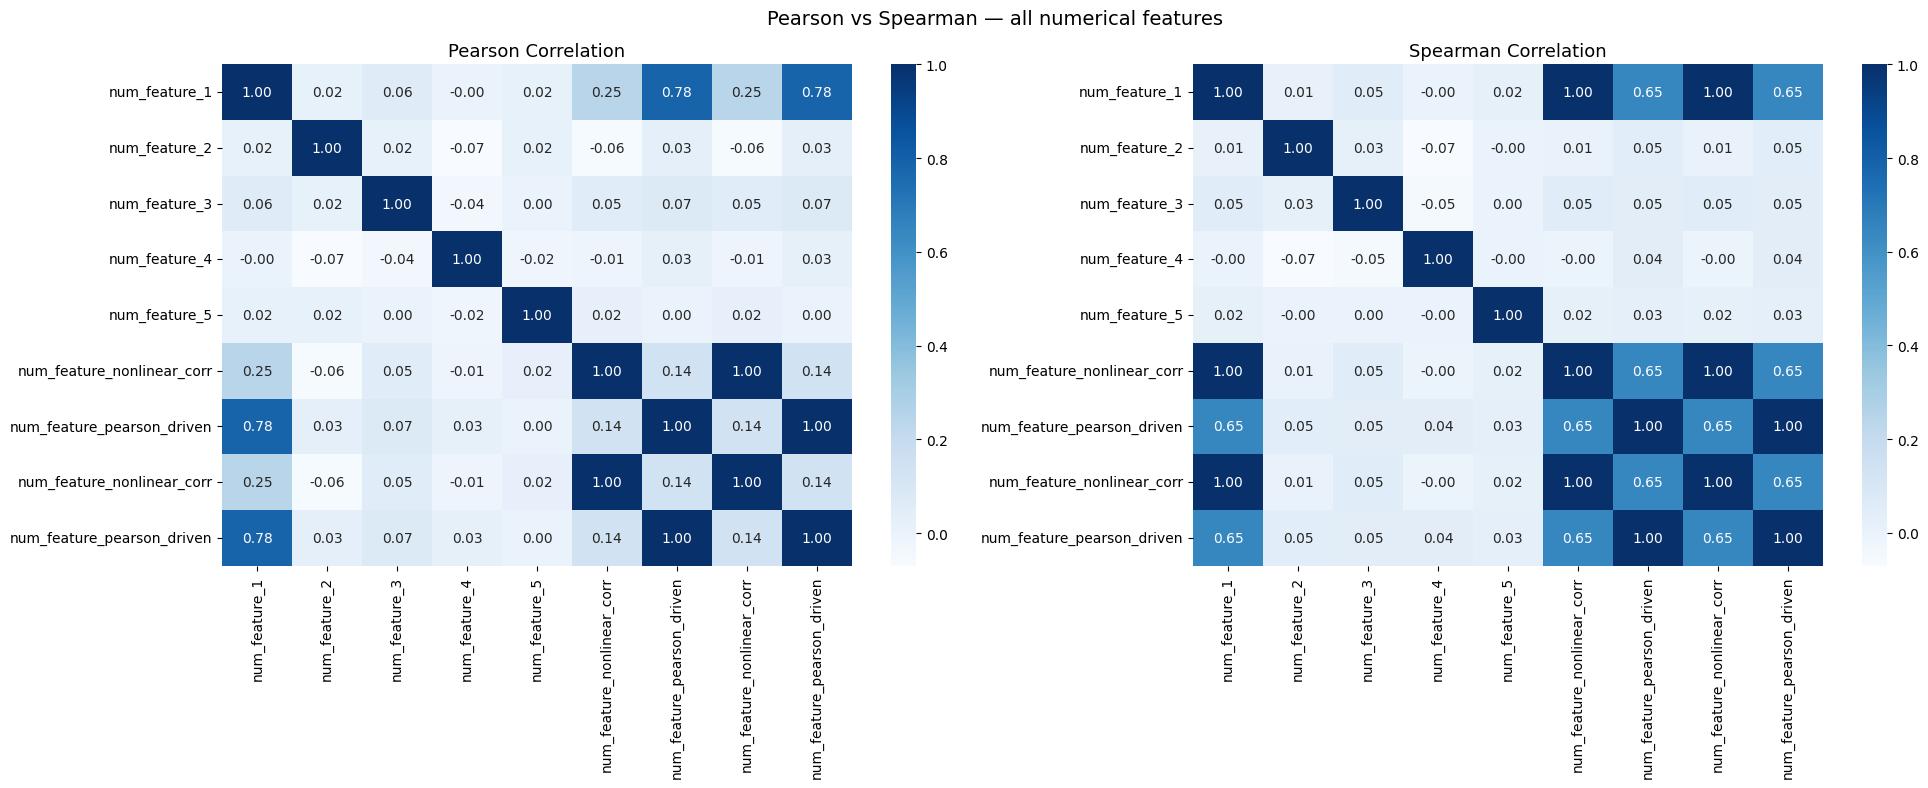

In [19]:
# Include the two engineered features so the contrast shows clearly in the heatmap
new_corr_feat = ['num_feature_nonlinear_corr', 'num_feature_pearson_driven']
pearson_corr  = dataset_train[num_cols + new_corr_feat].corr(method='pearson')
spearman_corr = dataset_train[num_cols + new_corr_feat].corr(method='spearman')

_ = plotter.plot_comparison_heatmaps(
    pearson_corr,
    spearman_corr,
    title_a='Pearson Correlation',
    title_b='Spearman Correlation',
    suptitle='Pearson vs Spearman — all numerical features',
)

#### It is easy to notice how the highest correlation in the matrix differs for spearman and pearson

Reference: [PhiK tutorial notebook](https://colab.research.google.com/github/KaveIO/PhiK/blob/master/phik/notebooks/phik_tutorial_basic.ipynb)

In [20]:
interval_cols = plotter.num_cols

phik_overview = dataset_train.phik_matrix(interval_cols=interval_cols, dropna=True)
phik_overview

,num_feature_1,num_feature_2,num_feature_3,num_feature_4,num_feature_5,cat_feature_1,cat_feature_2,cat_feature_3,num_feature_nonlinear_corr,num_feature_pearson_driven,cat_feature_corr,target
num_feature_1,1.000000,0.190872,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.906639,0.938620,0.000000,0.373460
num_feature_2,0.190872,1.000000,0.166126,0.000000,0.000000,0.000000,0.060337,0.000000,0.171565,0.156667,0.000000,0.611912
num_feature_3,0.000000,0.166126,1.000000,0.000000,0.000000,0.000000,0.047430,0.000000,0.000000,0.081821,0.000000,0.000000
num_feature_4,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.145558,0.126084,0.000000
num_feature_5,0.000000,0.000000,0.000000,0.000000,1.000000,0.133209,0.000000,0.000000,0.000000,0.000000,0.118238,0.079923
cat_feature_1,0.000000,0.000000,0.000000,0.000000,0.133209,1.000000,0.120540,0.118977,0.000000,0.000000,0.435553,0.518736
cat_feature_2,0.000000,0.060337,0.047430,0.000000,0.000000,0.120540,1.000000,0.000000,0.000000,0.000000,0.017666,0.083154
cat_feature_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.118977,0.000000,1.000000,0.000000,0.000000,0.000000,0.101403
num_feature_nonlinear_corr,0.906639,0.171565,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.842474,0.000000,0.030244
num_feature_pearson_driven,0.938620,0.156667,0.081821,0.145558,0.000000,0.000000,0.000000,0.000000,0.842474,1.000000,0.000000,0.256203


### Are all the correlation significant?
* The Phik provides also the significance of the correlation, to avoid dropping features highly correlated if not significantly.

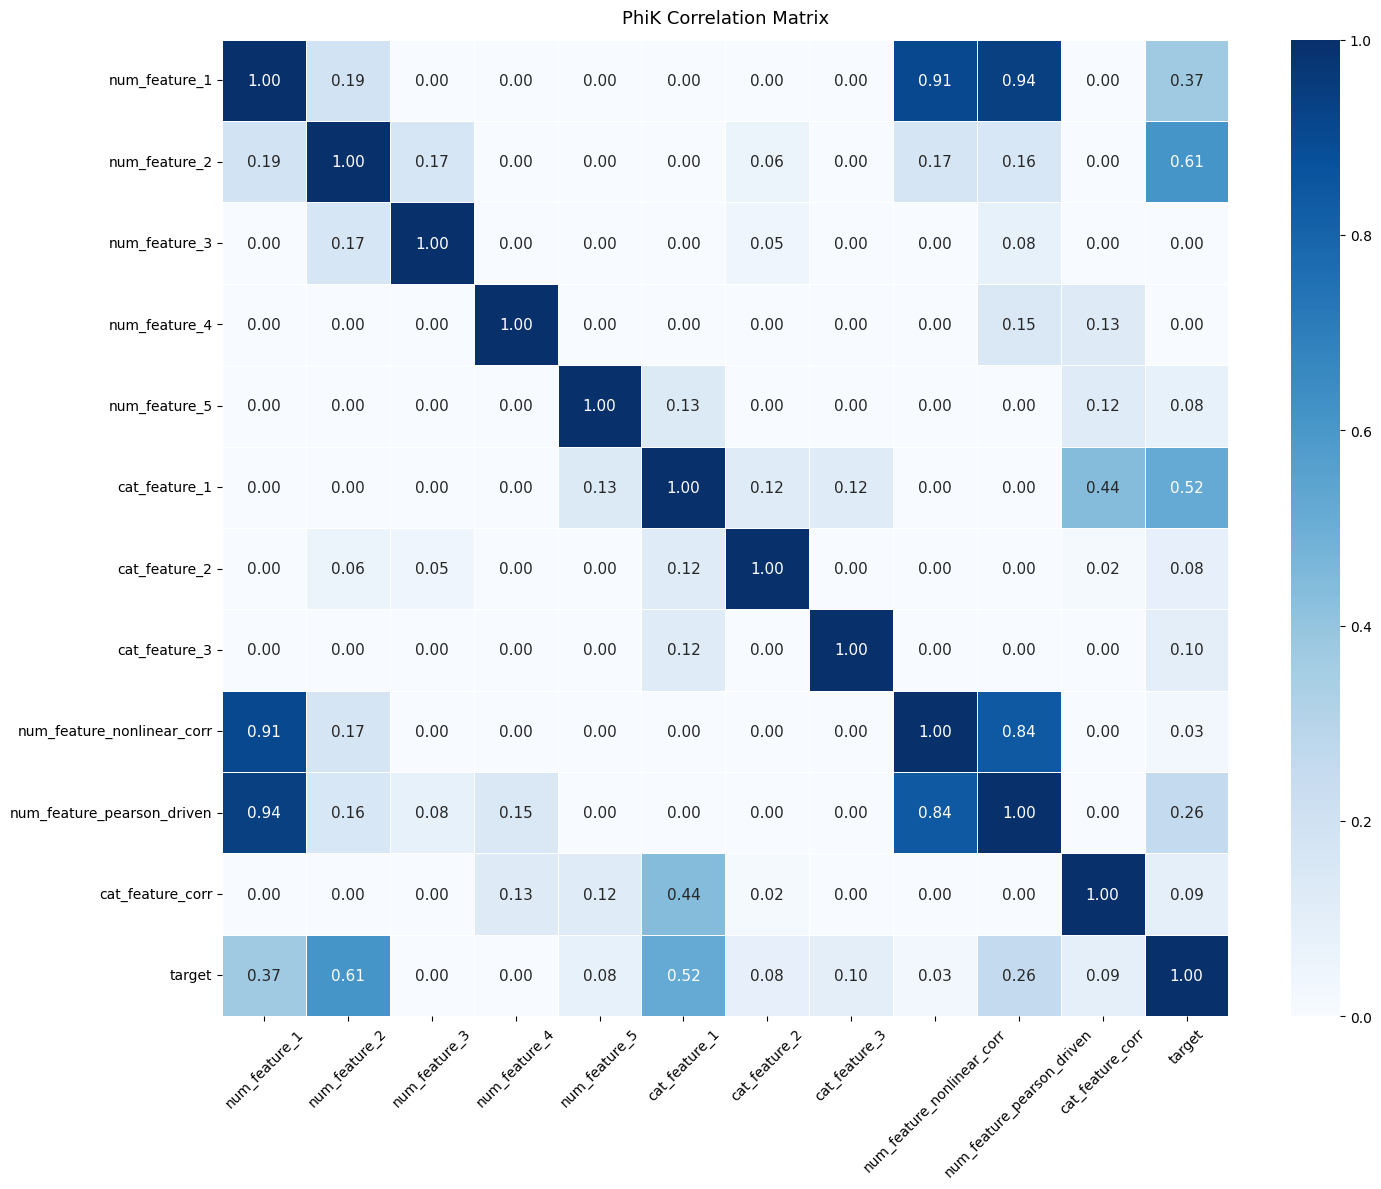

In [21]:
_ = plotter.plot_phik_heatmap(
    phik_overview,
    title="PhiK Correlation Matrix",
    figsize=(15, 12),
)

#### What to look for in the PhiK heatmap
PhiK ranges from 0 (no association) to 1 (perfect association) for **any** feature type (numerical, categorical, or mixed).

| PhiK value | Interpretation |
|---|---|
| < 0.15 | Negligible association |
| 0.15 – 0.5 | Moderate — worth investigating |
| > 0.5 | Strong — consider dropping one of the pair |

In our dataset:
- `cat_feature_corr` ↔ `cat_feature_1`: PhiK ≈ 0.41 — moderate, expected since `cat_feature_corr` was constructed to depend on `cat_feature_1`.
- `num_feature_2` ↔ `target`: PhiK ≈ 0.61 — strong signal, this is a genuinely predictive feature (not a redundancy to remove).

> Always cross-check correlation with **significance** (next cell) before dropping — a high PhiK on a small sample can be spurious.

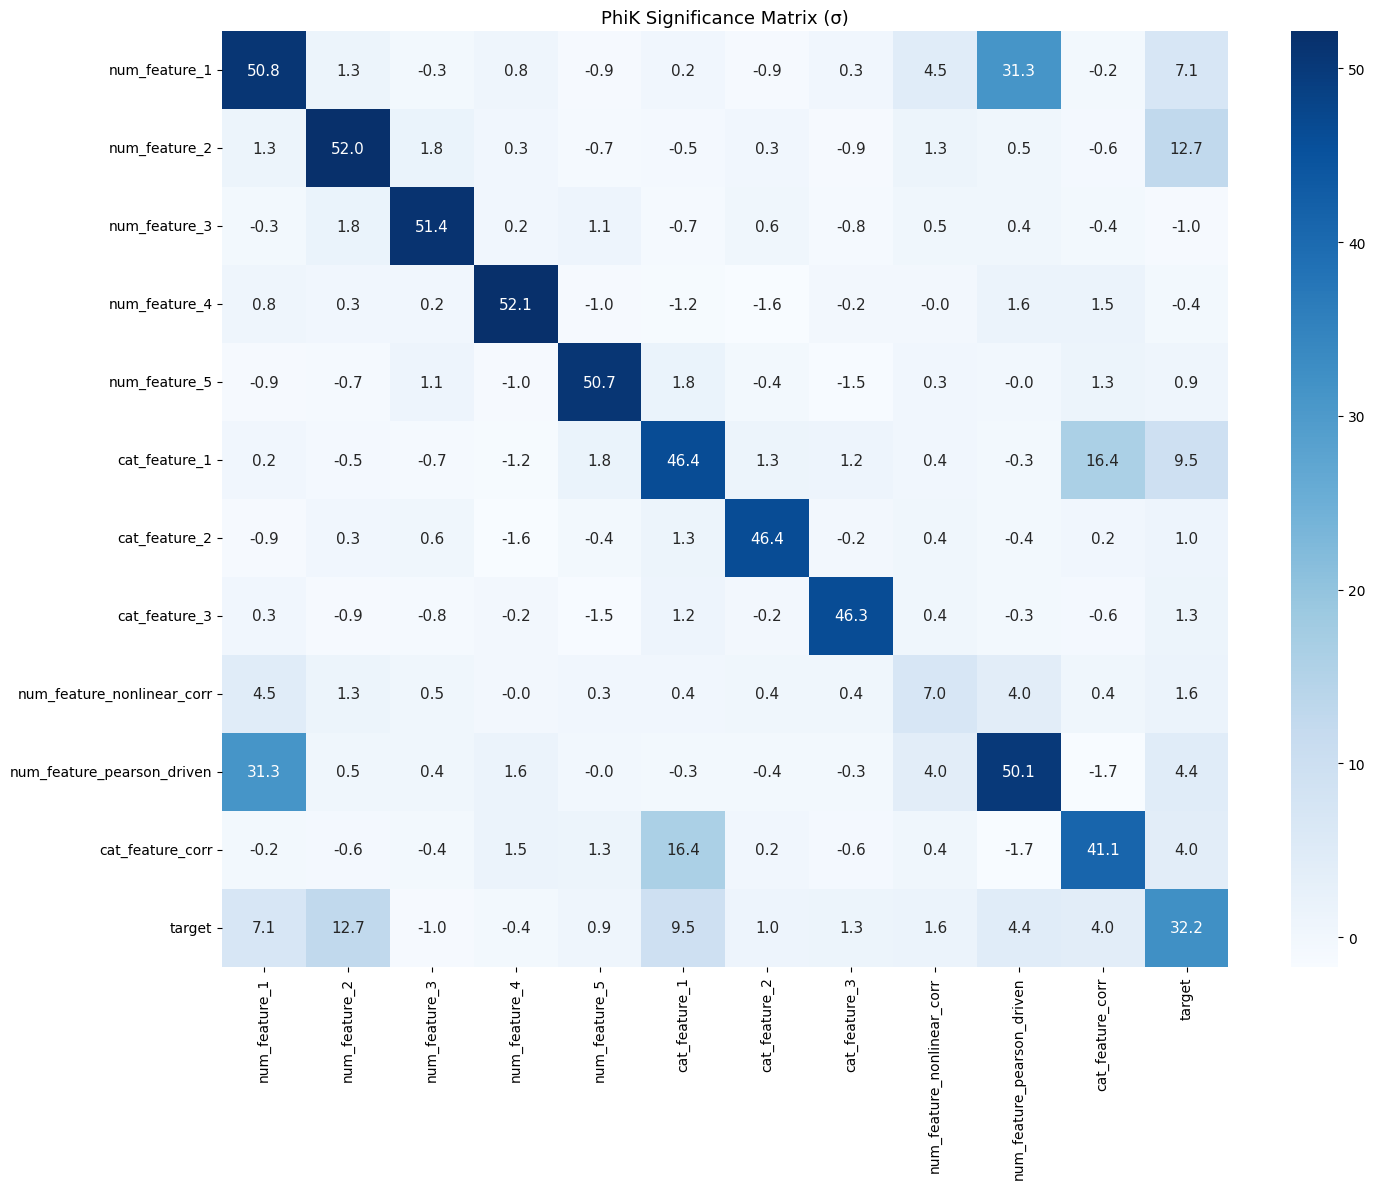

In [22]:
significance_overview = dataset_train.significance_matrix(interval_cols=interval_cols)

_ = plotter.plot_correlation_heatmap(
    significance_overview,
    title="PhiK Significance Matrix (σ)",
    figsize=(15, 12),
    fmt=".1f",
)